
MicroGrad demo

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

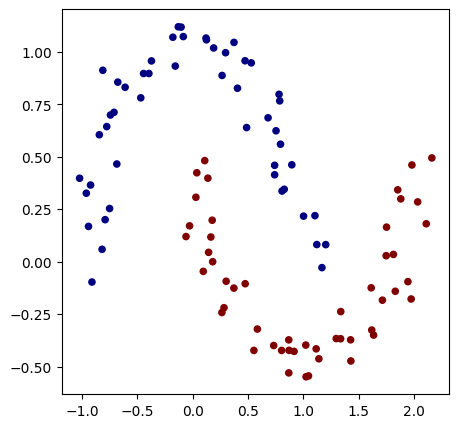

In [4]:
from sklearn.datasets import make_moons, make_blobs
X, y= make_moons(n_samples=100, noise=0.1)

y= y*2-1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')




In [5]:
#initialize a model
model= MLP(2, [16, 16, 1]) # 2 layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [6]:
# loss function
def loss(batch_size=None):

    # inline DataLoader :)
    if batch_size is None:
        Xb, yb= X, y
    else:
        ri= np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb= X[ri], y[ri]
    inputs= [list(map(Value, xrow)) for xrow in Xb]

    # forward the model to get scores
    scores= list(map(model, inputs))

    #svm "max-margin" loss
    losses= [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss= sum(losses) * (1.0/ len(losses))
    #L2 regularization
    alpha= 1e-4
    reg_loss= alpha* sum((p*p for p in model.parameters()))
    total_loss= data_loss + reg_loss

    # also get accuracy
    accuracy= [(yi>0) == (scorei.data> 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy)/len(accuracy)

total_loss, acc= loss()
print(total_loss, acc)

Value(data=0.8958441028683222, grad=0) 0.5


In [ ]:
# optimization
for k in range(100):

    #forward
    total_loss, acc= loss()

    # backward
    model.zero_grad
    total_loss.backward()

    # update(sgd)
    learning_rate= 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate*p.grad

    if k%1==0:
        print(f"step{k} loss {total_loss.data}, accuracy {acc*100}%")

step0 loss 0.8958441028683222, accuracy 50.0%
step1 loss 1.723590533697202, accuracy 81.0%
step2 loss 0.8230363277335903, accuracy 86.0%
step3 loss 4.080965629509381, accuracy 50.0%
step4 loss 2.6817095661961656, accuracy 56.99999999999999%
step5 loss 1.6549075911269435, accuracy 80.0%
step6 loss 8.907575391468523, accuracy 50.0%
step7 loss 0.7107834517851829, accuracy 86.0%
step8 loss 0.9866688831709715, accuracy 80.0%
step9 loss 0.5710977934141563, accuracy 88.0%
step10 loss 0.7387968028085765, accuracy 85.0%
step11 loss 0.7616036542194471, accuracy 82.0%
step12 loss 0.8441289919289257, accuracy 88.0%
step13 loss 0.8999277485094224, accuracy 87.0%
step14 loss 1.071477123514574, accuracy 83.0%
step15 loss 1.3185476715517637, accuracy 82.0%
step16 loss 1.7378357195166296, accuracy 73.0%
step17 loss 2.2285939973005413, accuracy 81.0%
step18 loss 1.6226128534016815, accuracy 87.0%
step19 loss 2.178631514725525, accuracy 84.0%
step20 loss 2.34102200616014, accuracy 84.0%
step21 loss 2.491

(-1.548639298268643, 1.951360701731357)

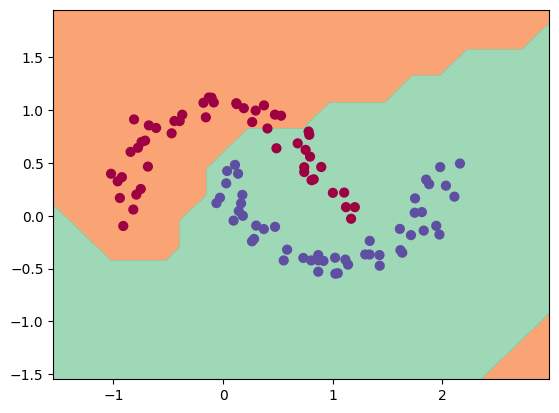

In [ ]:
h= 0.25
x_min, x_max= X[:, 0].min() -1, X[:, 0].max() + 1
y_min, y_max= X[:, 1].min() -1, X[:, 1].max() + 1
xx, yy= np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))
Xmesh= np.c_[xx.ravel(), yy.ravel()]
inputs= [list(map(Value, xrow)) for xrow in Xmesh]
scores= list(map(model, inputs))
Z= np.array([s.data>0 for s in scores])
Z= Z.reshape(xx.shape)

fig= plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:,0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(yy.min(), xx.max())
plt.ylim(yy.min(), yy.max())